In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import math
from scipy.optimize import curve_fit
import powerlaw

# Seaborn has way better visualizations and its built on top of matplotlib
import seaborn as sns
from scipy.optimize import curve_fit

In [27]:
# Run before running the graph code cause it preloads the nodes
nodes = pd.read_csv('./GEPHI/project_nodes.csv')

# Same idea as the professors code in Week 3
all_degrees = nodes['Degree'].values
kmin = max(1, all_degrees.min())
kmax = all_degrees.max()


In [ ]:
# -------------------------------------------------------------
# DEGREE DISTRIBUTION
#--------------------------------------------------------------

Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit
Degree exponent (γ): 2.262738468326398
This network is in Scale-Free Regime


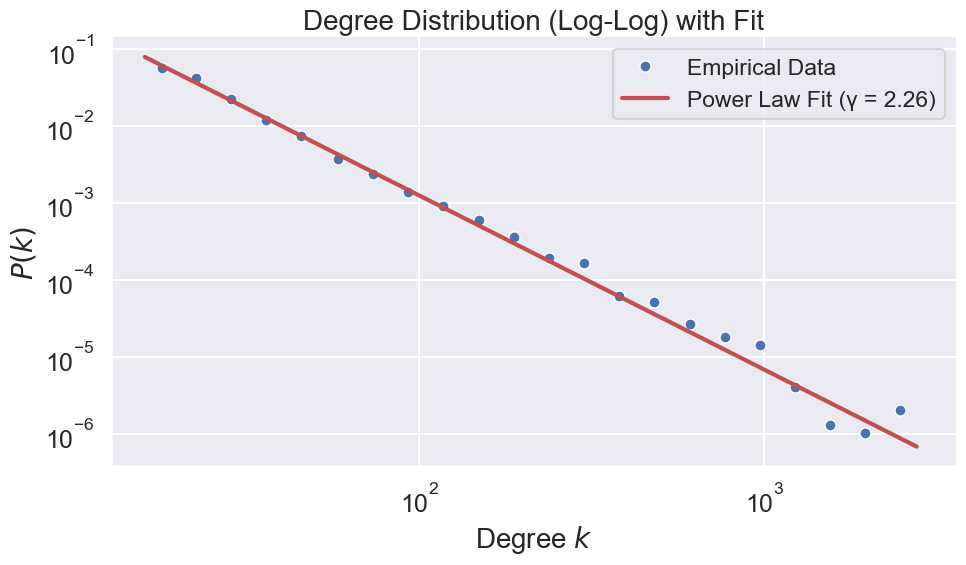

In [41]:
# Will use the power law library since that is WAY more reliable
# https://github.com/schae234/powerlaw
fitted_vals = powerlaw.Fit(all_degrees)
gamma = fitted_vals.alpha
xmin = fitted_vals.xmin

# Now I have the degree exponent (gamma)
print(f"Degree exponent (γ): {gamma}")
# From section 4.7, going to check what regime this falls into, based off the gamma I just got
# Anomalous regime (γ <= 2)
if gamma <= 2:
    print("This network is in Anomalous Regime")
# Scale-Free regime (2 < γ < 3)
elif 2 < gamma < 3:
    print("This network is in Scale-Free Regime")

# Random network regime (3 > γ)
elif 3 > gamma:
    print("This network is in Random Network Regime")

plt.figure(figsize=(10, 6))
fig = fitted_vals.plot_pdf(
    color=sns.color_palette("deep")[0],
    marker='o',
    markersize=8,
    markeredgecolor='white',
    markeredgewidth=1,
    linestyle='none',
    label='Empirical Data'
)

fitted_vals.power_law.plot_pdf(
    color=sns.color_palette("deep")[3],
    linestyle='-',
    linewidth=3,
    ax=fig,
    label=f'Power Law Fit (γ = {gamma:.2f})'
)

plt.xlabel(r"Degree $k$", fontsize=20)
plt.ylabel(r"$P(k)$", fontsize=20)
plt.title(r"Degree Distribution (Log-Log) with Fit", fontsize=20)
plt.legend()

# Setting the axis limits. Same as the professors code
ax = plt.gca()
ax.set_xlim(xmin * 0.8, max(all_degrees) * 1.3)

sns.despine()

plt.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.savefig("./Images/degree_dist_powerlaw.png", dpi=300, bbox_inches='tight')
plt.show()


plt.show()


In [ ]:
""# -------------------------------------------------------------
# LOADING GRAPH FIRST BEFORE THE OTHER CALCULATIONS
#--------------------------------------------------------------

In [2]:
G = nx.read_graphml("./NetworkFiles/network_graph_symptom.graphml")

In [ ]:
# -------------------------------------------------------------
# Number of connected components
#--------------------------------------------------------------

In [4]:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.number_connected_components.html
num_con_comps = nx.number_connected_components(G)
print(f"Number of connected components: {num_con_comps}")

Number of connected components: 387


In [ ]:
# -------------------------------------------------------------
# Degree Distri
#--------------------------------------------------------------